# Compute fields near beam in co-moving frame

In [1]:
from math import *
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
from scipy.optimize import root
from numpy.linalg import norm as vabs

import special_relativity as SR

In [2]:
mec2 = sc.m_e*sc.c**2/sc.e
γ = 20.0e6 / mec2
β = sqrt(1.0-1.0/γ**2)
print(f'β = {β}')
print(f'γ = {γ}')

β = 0.9996735468055344
γ = 39.13902367147747


### particles on circular trajectory in lab frame

3 particles following each other with 0.01mm separation

In [13]:
# trajectory
Rt = 0.3
α = lambda t: β*sc.c*t / Rt
α_t = β*sc.c / Rt

# time-dependent particle position, velocity and acceleration
X = lambda t: Rt * np.array([cos(α(t))-1.0,sin(α(t)),0.0])
B = lambda t: β * np.array([-sin(α(t)),cos(α(t)),0.0])
B_t = lambda t: β * α_t * np.array([-cos(α(t)),-sin(α(t)),0.0])

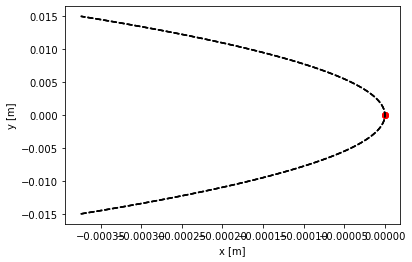

In [20]:
# t_traj is valid for all particles
# t1 and t3 are leading/trailing by 0.01mm
t_traj = np.linspace(-50e-12, 50e-12, 101)
X1_traj = np.stack([X(t) for t in t_traj - 1e-5/(β*sc.c)])
X2_traj = np.stack([X(t) for t in t_traj])
X3_traj = np.stack([X(t) for t in t_traj + 1e-5/(β*sc.c)])

plt.plot(X1_traj[:,0],X1_traj[:,1],'k--')
plt.plot(X2_traj[:,0],X2_traj[:,1],'k--')
plt.plot(X3_traj[:,0],X3_traj[:,1],'k--')
plt.scatter([X1_traj[50,0],X2_traj[50,0],X3_traj[50,0]],[X1_traj[50,1],X2_traj[50,1],X3_traj[50,1]],color='r')
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.show()

### transform trajectory to co-moving frame

In [21]:
lab2beam = SR.LorentzTransform(γ,β*np.array([0.0, 1.0, 0.0]))
lab2beam.matrix

array([[ 39.13902367,  -0.        , -39.12624661,  -0.        ],
       [ -0.        ,   1.        ,   0.        ,   0.        ],
       [-39.12624661,   0.        ,  39.13902367,   0.        ],
       [ -0.        ,   0.        ,   0.        ,   1.        ]])

In [22]:
# compute 4-vector of particle position in lab frame
L1_pos4 = np.array([np.concatenate(([sc.c*t],X1_traj[i])) for i,t in enumerate(t_traj)])
L2_pos4 = np.array([np.concatenate(([sc.c*t],X2_traj[i])) for i,t in enumerate(t_traj)])
L3_pos4 = np.array([np.concatenate(([sc.c*t],X3_traj[i])) for i,t in enumerate(t_traj)])
print(f'c*t1 in L = {L1_pos4[0,0]} ... {L1_pos4[-1,0]} m')
print(f'c*t2 in L = {L2_pos4[0,0]} ... {L2_pos4[-1,0]} m')
print(f'c*t3 in L = {L3_pos4[0,0]} ... {L3_pos4[-1,0]} m')

c*t1 in L = -0.014989622900000001 ... 0.014989622900000001 m
c*t2 in L = -0.014989622900000001 ... 0.014989622900000001 m
c*t3 in L = -0.014989622900000001 ... 0.014989622900000001 m


In [23]:
# apply Lorentz transform
CM1_pos4 = np.apply_along_axis(lab2beam, axis=1, arr=L1_pos4)
CM2_pos4 = np.apply_along_axis(lab2beam, axis=1, arr=L2_pos4)
CM3_pos4 = np.apply_along_axis(lab2beam, axis=1, arr=L3_pos4)
print(f'c*t1 in CM = {CM1_pos4[0,0]} ... {CM1_pos4[-1,0]} m')
print(f'c*t2 in CM = {CM2_pos4[0,0]} ... {CM2_pos4[-1,0]} m')
print(f'c*t3 in CM = {CM3_pos4[0,0]} ... {CM3_pos4[-1,0]} m')

c*t1 in CM = -0.00023597246289519536 ... 0.0010175214323442372 m
c*t2 in CM = -0.0006267466220349904 ... 0.0006267466220349904 m
c*t3 in CM = -0.0010175214323442372 ... 0.00023597246289519536 m


In [40]:
# find the trajectory point at time zero in CM frame
def interpolate_zero(traj4):
    id2 = np.searchsorted(traj4[:,0], 0.0)
    id1 = id2-1
    t1 = traj4[id1,0]
    t2 = traj4[id2,0]
    frac = -t1/(t2-t1)
    return (1.0-frac)*traj4[id1] + frac*traj4[id2]

interpolate_zero(CM1_pos4)

array([ 8.47032947e-22, -2.11497515e-04, -2.87742303e-04,  0.00000000e+00])

In [41]:
CM1_X0 = interpolate_zero(CM1_pos4)
CM2_X0 = interpolate_zero(CM2_pos4)
CM3_X0 = interpolate_zero(CM3_pos4)

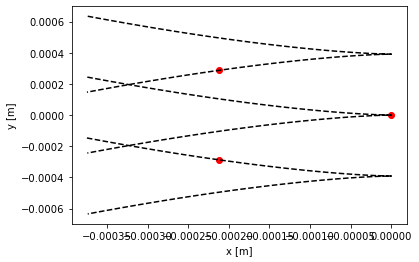

In [42]:
CM1_X_traj = CM1_pos4[:,1:4]
CM2_X_traj = CM2_pos4[:,1:4]
CM3_X_traj = CM3_pos4[:,1:4]

plt.plot(CM1_X_traj[:,0],CM1_X_traj[:,1],'k--')
plt.plot(CM2_X_traj[:,0],CM2_X_traj[:,1],'k--')
plt.plot(CM3_X_traj[:,0],CM3_X_traj[:,1],'k--')
plt.scatter([CM1_X0[1],CM2_X0[1],CM3_X0[1]],[CM1_X0[2],CM2_X0[2],CM3_X0[2]],color='r')
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.show()